在这一章中，我们将从GPU的硬件视角转向计算视角，这是本书的主要目标。我们将首先介绍GPU编程和建立三个不同平台的基本方法，即CUDA、ROCm和Anaconda。将在这里重新探讨GPU的实际使用与三个平台。

将讨论Python编程与GPU代码调用集成的概念。Anaconda用户和Python编程爱好者将通过Anaconda与CuPy和Numba（以前叫Accelerate）在程序代码中调用GPU。此外，我们还将学习一些GPU编程、GPU可编程平台、CUDA、CUDA库、OpenCL和ROCm的基础知识。

接下来，我们将探讨Python编程方面：PyCUDA、PyOpenCL、CuPy和Numba，它们是使用GPU加速Python代码的非常方便的方法。我们还将学习如何在系统上设置Anaconda。这个知识将帮助我们理解为什么用Python编程GPU是如此的方便（即使没有或有限的C/C++知识）。

为此，本章将讨论以下主题：
- GPU可编程平台
- CUDA基本概念
- ROCm基本概念
- Anaconda Python 分布
- 支持GPU的Python编程

# GPU可编程平台

因为我们的主要课程是GPU计算，所以从计算的角度学习GPU编程的基础知识是非常重要的。GPU编程是GPU计算的基础，这里需要思考的问题是，它在GPU计算中的重要性是什么？要知道答案，让我们首先了解编程和计算之间的基本区别。下面是一个简短的比较：

<table border="1" style="border-collapse: collapse;width: 100%">
<tbody>
<tr>
<td class="CDPAlignCenter CDPAlign">
<p><strong>编程</strong></p>
</td>
<td class="CDPAlignCenter CDPAlign">
<p><strong>计算</strong></p>
</td>
</tr>
<tr>
<td>
<p>包括开发程序。</p>
</td>
<td>
<p>包括通过程序执行计算。</p>
</td>
</tr>
<tr>
<td>
<p>打算以一种广义的方式解决多个问题。</p>
</td>
<td>
<p>专注于解决一个跨学科的问题。</p>
</td>
</tr>
<tr>
<td>
<p>编程应用于更广泛的场景。</p>
</td>
<td>
<p>计算应用于一个特定的场景，该场景基于这些更广泛的场景并从中选择</p>
</td>
</tr>
<tr>
<td>
<p>这里有一个简单的例子：当列出购买商品的所有步骤时，不管其品牌如何，我们都遵循一种编程方法，比如说，购买计算机组件的步骤。</p>
</td>
<td>
<p>这里有一个简单的例子：当列出购买某一特定品牌的商品的步骤时，我们遵循的是一种计算方法，比如说，购买Seamic 850W黄金系列电脑电源的步骤。</p>
</td>
</tr>
</tbody>
</table>

正如我们所看到的，计算是编程的一个非常关键的子集，在计算研究领域非常重要。GPU可编程平台为您提供了一个接口，这样您就可以用GPU一步一步地具体解决计算问题。GPU编程和GPU计算都遵循一组通用的指令，但它们的特性不同，后者高度关注于特定的计算任务。

进入GPU编程新世界的开发人员已经熟悉以下语法代码：

以下是了解GPU程序与前面代码的区别的一种非常基本的方法：

如我们所见，整个代码仍然存在于单个程序中，但是本质上密集的任务集被交给GPU执行。

有关从CPU到GPU的迁移的更广泛的观点，请参阅进一步的阅读：常规CPU计算与GPU计算，然后我们继续本章的下一节。在接下来有关CUDA、ROCm和Python的部分中，我们将介绍所有的基础知识，以便您可以开始动手使用GPU支持的Python程序来执行不同类型的计算任务。在这本书中，我们将使用最新的64位版本的ubuntu18.04.2操作系统进行实践。

# CUDA基本概念

由于我们在前面的章节中已经讨论了计算统一设备体系结构（CUDA）的各个要点，现在让我们重点讨论它的技术方面和GPU的可编程性。

除了CUDA独有的安装过程之外，本文将简要讨论的其余概念对于在所有平台上开始GPU编程都很有用。

## 安装和测试

在我们讨论一些基本的GPU编程概念之前，我们有必要在结束DIY部分的同时，重新回顾我们在第2章“设计GPU计算策略”中前面介绍的CUDA安装和测试过程。一个新的Ubuntu 18.04 Linux 安装的一步一步的屏幕截图被演示。正如我们前面讨论的，只涉及两个基本步骤。

它需要执行以下顺序任务：

1. 驱动程序安装：驱动程序安装可以通过安装最新版本的NVIDIA图形驱动程序从可用的Ubuntu存储库通过额外的驱动程序。
2. CUDA toolkit安装：这个工具箱包的名字是`nvidia-cuda-toolkit`，安装后它还会设置 NVIDIA CUDA 编译器（NVCC）驱动程序的路径。建议在安装后重新启动，之后您可以从任何终端使用nvcc命令编译CUDA程序源代码文件。您可以使用以下代码验证新的CUDA安装：

然后检查NVCC版本：

nvcc编译的简单语法如下：

正如我们在这里看到的，CUDA源文件的扩展名是.cu。我们下一步需要的是一个IDE，这将在本书后面介绍。

默认情况下，选择Linux存储库中可用的CUDA工具包总是一个好的做法，因为它在升级Linux系统时非常方便。如果配置不当，手动安装单独下载的版本可能会导致系统不稳定。但是，如果您根据特定的应用程序要求选择有多个CUDA版本，您可以从以下存档链接安装和配置它们。在选择CUDA版本和操作系统后，它还会显示相关文档。

点击此链接下载CUDA工具包：https://developer.nvidia.com/cuda-toolkit-archive。

为保持系统稳定性，在基于上一个链接更新存储库后，请使用以下格式仅安装特定的工具箱版本：

x-x是指CUDA工具包的版本号。例如，cuda-toolkit-9-0将安装cuda9.0。

不要安装cuda或cuda-x-x软件包，因为这两个软件包都会尝试在cuda中安装新的NVIDIA驱动程序，因此可能会破坏先前安装的默认设置的现有NVIDIA图形（其他专有驱动程序）。

## 计算能力

每个NVIDIA GPU都有自己的通用规范和可用功能。这些参数可以通过compute capability更好地理解，compute capability是NVIDIA设定的标准，用于根据每个GPU的硬件和软件规格/特性对其进行分类。通过计算能力，NVIDIA GPU可以很容易地根据这些分类进行比较。随着CUDA API的发展，计算能力也在不断提高。最新的cudasdk10.1对计算能力的支持是从3.0到7.5，用于NVIDIA GPU，Kepler、Maxwell、Pascal、Volta和图灵体系结构。有关详细信息，请访问以下链接：https://developer.nvidia.com/cuda-gpus。

## 线程、块和网格

在寻址GPU程序内核时，有效地操纵线程、块和网格的数量，使我们能够充分利用GPU设备的计算吞吐量。下图演示了网格的组件。我们可以看到它是由块组成的。一个单一的块也被放大和说明，以显示它所包含的线程。

块（1，1）的组件是12个线程，每个线程用箭头表示。请注意，网格中的每个块（以绿色显示）还包括12个这样的箭头，以表示各个线程。网格中的每个块的结构如下：

这三种形式的CUDA代码实现将帮助您根据计算需求管理处理GPU设备代码执行的各种方式。CUDA程序可以在一组线程块中包含多个线程的情况下启动。一组线程块依次形成一个网格。当使用多组线程块时，我们实际上使用了多个网格，因此可以最大化整个CUDA代码执行过程中使用的线程总数。

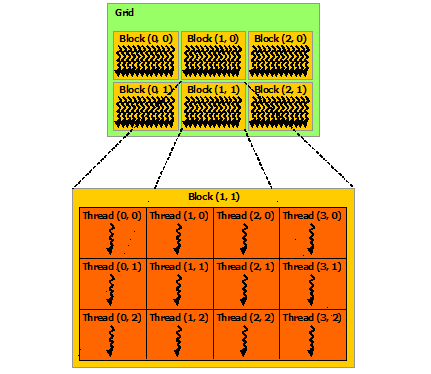

### Threads

线程是在GPU上并行执行以处理单个内核作业的基本单元。GPU线程与CPU线程非常相似，唯一的区别是，在GPU的情况下，可用线程的数量可能要高得多。

### 块

正如我们在上图中看到的，线程块是线程的集合。每个块中的线程数受限于GPU的体系结构。例如，在属于Maxwell架构的NVIDIA GeForce Titan X GPU中，块中的最大线程数是1024。但是尽管有这样的限制，GPU程序仍然可以使用大量的块来代替。这允许程序最大限度地实现线程并行化，特别是在高性能GPU上。

### 网格

更进一步说，网格是块的集合。根据NVIDIA GPU的计算能力，您可以根据网格的最大线程数和块数设置块的最大大小。通过这种方式，您将能够最大限度地利用GPU的计算能力和最大的占用率。为了方便起见，NVIDIA提供了一个CUDA占用率计算器用于估算：

- https://developer.download.nvidia.com/compute/cuda/CUDA_Occupancy_calculator.xls

- https://xmartlabs.github.io/cuda-calculator/

## 管理内存

正如传统的C++使用标准的C函数来处理内存一样，CUDA也以类似的方式使用它自己的内存管理功能。CUDA不使用C函数来管理设备（GPU）内存变量。它有自己的函数为GPU设备变量分配内存，但它们的设计与C中的语法类似。另一方面，通过CUDA进行统一内存分配的变量可以在主机和设备上使用。C++代码被称为主机代码，而CUDA代码称为设备代码。在通过设备内核开发GPU程序和执行代码时，以下函数非常常用：

<table border="1" style="border-collapse: collapse;width: 100%">
<tbody>
<tr>
<td class="CDPAlignCenter CDPAlign">
<p><strong>Conventional C/C++ functions</strong></p>
</td>
<td class="CDPAlignCenter CDPAlign">
<p><strong>CUDA version of the same functions</strong></p>
</td>
</tr>
<tr>
<td>
<p><kbd>malloc</kbd></p>
</td>
<td>
<p><kbd>cudaMalloc</kbd></p>
</td>
</tr>
<tr>
<td>
<p><kbd>memcpy</kbd></p>
</td>
<td>
<p><kbd>cudaMemcpy</kbd></p>
</td>
</tr>
<tr>
<td>
<p><kbd>free</kbd></p>
</td>
<td>
<p><kbd>cudaFree</kbd></p>
</td>
</tr>
</tbody>
</table>

`cudaMemcpyHostToDevice`和`cudaMemcpyDeviceToHost`是CUDA API中的两个函数，可与主机和设备变量互换使用。它们非常重要，用于在CPU和GPU之间传输数据。

## 统一内存访问（UMA）

此功能允许数据指针在GPU设备上分配CPU和GPU都可以访问的内存。通过这种共享内存访问，就不需要为主机变量分配CPU。下面的声明示例将UMA与传统的内存分配区分开来：

<table border="1" style="border-collapse: collapse;width: 100%">
<tbody>
<tr>
<td>
<p><strong>Conventional CPU memory allocation</strong></p>
</td>
<td>
<p><strong>Unified memory allocation</strong></p>
</td>
</tr>
<tr>
<td>
<pre>char *data;<br>data = (char *)malloc(N)</pre></td>
<td>
<pre>char *data<br>cudaMallocManaged(&amp;data, N)</pre></td>
</tr>
</tbody>
</table>

通过使用`cudaMallocManaged`，我们可以在GPU上分配内存，这些内存可以在CPU和GPU之间迁移。因此，通过统一内存访问，我们可以将数据指针传递给CPU函数以及GPU内核！

## 动态并行

具有3.5或更高计算能力的GPU设备可以利用一种主要是减少CPU-GPU交互的功能，而不是直接从GPU工作。使用动态并行性，在运行时执行期间，线程可以决定在GPU本身上启动配置。因此，在CPU和GPU之间传输执行控制和数据的需求可以大大减少。

## 预定义库

预定义库基本上是现有的模块，您可以在代码中实现这些模块，这样就不必花时间自己开发它们。每个预定义的库都专注于计算特定的任务。通过在代码中使用预定义的库，您可以专注于主要的项目目标，而不必担心公共核心特性的额外开发。

例如，您可以使用预定义的CUDA数学库来加速您的数学函数，而不必自己编写函数。这有助于您更好地专注于解决手头的实际计算问题。NVIDIA还提供了可与CUDA一起用于特定应用程序的现成库。以下列出了其中一些库：

- cuDNN：这是一个用于深度神经网络的原语库，广泛用于深度学习框架，包括Caffe、Caffe2、-Chainer、Keras、MATLAB、MxNet、TensorFlow和PyTorch
- cuFFT：快速傅立叶变换实现的执行速度是纯CPU替代方案的10倍
- cuBLAS：计算密集型运算的基本线性代数子程序的实现
- CUDA数学库：加速标准数学函数库
- cuSPARSE：稀疏矩阵的加速BLAS算法
- cuRAND:加速随机数生成 Random Number Generation（RNG）
- cuSOLVER:计算机视觉、计算流体力学、计算化学和线性优化应用的密集和稀疏直接求解器
- AmgX：用于模拟和隐式非结构方法的加速线性求解器

在第6章中，我们将通过CUDA-C示例学习更多关于这个模型中编程的知识，使用CUDA和PyCUDA。

## OpenCL

除了CUDA-C之外，CUDA工具包还附带OpenCL支持。这里需要注意的唯一额外步骤是安装OpenCL headers包：

在此之后，通过使用–lOpenCL标志运行gcc或g++编译器，您将能够编译包含OpenCL代码的.c或.cpp文件。使用gcc编译.c文件的命令如下：

使用g++的.cpp文件的相应命令如下：

如前所述，CUDA和OpenCL的基本区别在于跨平台兼容性和代码语法。它们的一般适用性保持不变。我们将通过第6章，使用CUDA和PyCUDA，以及第7章，使用ROCm和PyOpenCL来探讨这些异同。

# ROCm基本概念

第三章利用NVIDIA和AMD搭建了一个GPU计算平台，讨论了AMD-ROCm，并与NVIDIA-CUDA进行了比较。就像我们在本章上一节所做的那样，让我们以类似的方式来研究Radeon开放计算平台。

AMD ROCm包含了一套基本的方法来建立一个开放计算的GPU编程平台。在AMD或NVIDIA GPUs上开始编程需要知道的基本ROCm概念如下。

## 安装程序和测试

根据官方文档，ROCm安装需要执行以下与ubuntu18.04兼容的基于终端的任务：

1. 使用以下命令更新系统并安装`libnuma-dev`：

2. 使用以下命令添加apt存储库：

3. ROCm包的名称为`rocm-dkms`，使用以下命令使用最近更新的apt存储库列表更新系统后，可以安装该包：

4. 在安装ROCm之后，您必须确保您作为一个用户包含在视频组中。只有这样，您才能访问GPU：

5. 上一个命令将显示您是否已经是视频组的成员。如果不是，请使用以下命令执行相同操作：

重新启动后，再次使用groups命令会显示您现在是Ubuntu Linux系统上视频组的成员。

6. 您可以使用以下内容验证新的ROCm安装：

7. 使用以下命令设置路径，以便以后更容易访问：

8. 可以使用以下命令重新加载Bash shell，以使更改立即生效：

现在，您可以从任何终端使用`rocminfo、clinfo`等命令以及所有其他相关的ROCm命令。ROCm还提供以下命令，其性质类似于`nvidia-smi`：

在AMD GPU上编译hcc（相当于NVIDIA CUDA上的nvcc）的语法如下：

正如我们所看到的，HC源文件的扩展与C++是相同的，即.cpp。hipcc（与AMD和NVIDIA GPU兼容）的简单语法如下：

HIP还使用.cpp扩展名。它是一个运行时库，在AMD ROCm平台的HC之上分层，并使用NVIDIA CUDA平台的NVCC编译器。

我们知道CUDA在研究领域的广泛使用，以及GitHub、GitLab等各种托管网站上提供的大量CUDA代码。如果你没有一个NVIDIA的GPU，而是AMD的GPU，你仍然可以很容易地测试各种CUDA转换的代码在低成本的AMD的GPU从现在开始！

## 芯片分类

每个AMD GPU也有自己的通用规范和可用功能。AMD GPU可以根据其芯片的代数进行分类。最新的ROCm SDK版本2.1支持第GFX7、GFX8和GFX9代AMD gpu，它们属于夏威夷、斐济、北极星和织女星体系结构。更多信息可以通过这个链接找到：https://rocm.github.io/hardware.html.

## ROCm组件（API），包括OpenCL

与CUDA类似，ROCm的三个主要组件具有类似的命名约定：
- HC:线程、平铺和范围
- HIP：线程、块和网格（与CUDA中完全相同）
- OpenCL：工作项、工作组和NDRanges

## 类似CUDA的HIP内存管理

正如传统的C++使用标准的C函数来处理内存一样，HIP也有类似于它使用的内存管理功能。C++代码被称为主机代码，而HIP代码称为设备代码。在开发或移植AMD/NVIDIA GPU程序以及通过设备内核执行代码时，HIP经常使用以下函数：

<table border="1" style="border-collapse: collapse;width: 100%">
<tbody>
<tr>
<td class="CDPAlignCenter CDPAlign">
<p><strong>CUDA version</strong></p>
</td>
<td class="CDPAlignCenter CDPAlign">
<p class="CDPAlignCenter CDPAlign"><strong>HIP version of the same functions</strong></p>
</td>
</tr>
<tr>
<td>
<p><kbd>cudaMalloc</kbd></p>
</td>
<td>
<p><kbd>hipMalloc</kbd></p>
</td>
</tr>
<tr>
<td>
<p><kbd>cudaMemcpy</kbd></p>
</td>
<td>
<p><kbd>hipMemcpy</kbd></p>
</td>
</tr>
<tr>
<td>
<p><kbd>cudaFree</kbd></p>
</td>
<td>
<p><kbd>hipFree</kbd></p>
</td>
</tr>
</tbody>
</table>

与CUDA类似，`hipMemcpyHostToDevic`e和`hipMemcpyHostToDevice`对应于CUDA上`cudaMemcpyHostToDevice`和`cudaMemcpyDeviceToHost`的作用。

## hipify

ROCm提供了一个独特的工具，可以轻松地将CUDA代码转换为HIP。以下是在终端上安装hipify的步骤：

1. 首先，安装所有依赖项以安装和运行hipify：

输出类似于：

2. 现在，我们将在相同的生成位置安装hipify：

前面的命令将显示如下输出：

3. 现在，要设置hipify命令，我们可以使用以下命令：

重新加载Bash shell：

现在，您可以使用以下命令轻松地将CUDA代码转换为HIP：

你可以使用任何你选择的用CUDA-C开发的.cu文件。

这个特性的有用之处在于能够实现跨平台的可移植性。我们将在第7章中了解更多关于这一点，使用ROCm和PyOpenCL。

## 预定义库

AMD还提供现成的库，用于特定于应用程序的ROCm。以下列出了其中一些库：

- MIOpen：类似于nvidiacuda上的cuDNN，amdrocm有MIOpen库，用于深层神经网络，可以用于TensorFlow和PyTorch深层学习框架。
- rocFFT:：用HIP编写的计算FFT的软件库。该库可用于NVIDIA和AMD GPU设备。
- rocBLAS：基本线性代数子程序的实现，用HIP编程语言实现，并为AMD的gpu优化。
- Open Compute Math Library (OCML)：包含250+个优化的数学函数，用于单精度、双精度和半精度。
- rocSPARSE：稀疏矩阵的加速BLAS为稀疏计算提供了基本的线性代数子程序。
- rocRAND：类似于cuRAND的加速RNG提供了生成伪随机数和准随机数的函数。
- rocSOLVER：与cuSOLVER类似，rocSOLVER是使用rocBLAS的ROCm平台上LAPACK功能子集的一个正在进行中的实现。LAPACK是数值线性代数的标准软件库。
- Hardware Accelerated Cosmology Code (HACC)：这个框架使用N体技术来模拟膨胀宇宙中在重力影响下无碰撞流体中结构的形成。HACMK已用C++语言移植到HCC编译器上。

我们将在第6章（使用CUDA和PyCUDA）以及第7章（使用ROCm和PyOpenCL）中了解更多关于此模型中编程的信息。

## OpenCL

我们已经知道，ROCm带有HC、HIP和OpenCL。如果您只需要OpenCL，而不是使用sudo apt install rocm dkms（我们前面在rocm安装步骤中提到过），那么替代命令是：

# 部署的Anaconda Python

Anaconda是一个用于包管理和部署的发行版。它通过Python和R（一种专注于统计计算的编程语言）促进了科学计算和机器学习的发展。Anaconda简化了管理各种软件包的过程以及它们的部署。Anaconda存储库为数据科学维护了1000多个专业构建的软件包。

它有一个名为conda的软件包管理系统来安装各种科学软件包。它还提供了一个构建特性，用于构建自己的Python包并将其上载到Anaconda服务器。conda可以用于安装、执行和更新包及其依赖项。它可以为任何语言的软件提供便利，即使它是为Python包设计的。

Anaconda发行版还包括一个名为Anaconda Navigator的图形用户界面，该界面无需使用命令即可简化conda的使用。anaconda2中Python的主版本是2.x，而anaconda3的主版本是pythonversion3.x。

## 在Ubuntu 18.04上安装Anaconda Python发行版

超过1200万用户使用Anaconda发行版，拥有1400多个数据科学软件包。它是用Python编写的，2012年由Continuum Analytics（现为Anaconda Inc.）首次发布。Anaconda发行版在BSD许可下是免费的开源版本，可用于Linux、Windows和macOS。以下是在Ubuntu 18.04上安装Anaconda Python发行版所需的步骤：

1. 在Ubuntu的终端上，逐步使用以下命令：

/tmp是下载安装程序的临时位置。要保留安装程序，可以跳过此命令。然后，使用以下命令下载Anaconda安装程序：

2. 要检查文件是否没有损坏，可以使用`sha256sum`命令验证文件的完整性：

输出如下：

3. 然后，您可以访问所有Anaconda安装程序

在这里，您可以使用web浏览器上的“查找”功能，根据页面上显示的最近下载的Anaconda版本的哈希来验证您在终端上看到的哈希。

`1821D4B623ED449E0ACB6DF3ECBABD3944CFA98F96A5234B7A102A7C0853DC6`散列可以通过复制并粘贴到查找工具上进行验证。找到带有该粘贴的哈希后，可以确认其完整性并继续安装：

当您输入上述命令启动安装程序时，将要求您查看Anaconda许可协议：

按Enter键，向下滚动浏览许可证，然后键入yes作为答案：

现在，您将看到一个接受默认Anaconda安装路径或选择其他路径的提示：

按照前面的代码，安装程序将要求您通过`~/.bashrc`文件将Anaconda路径添加到系统路径。

让我们继续相同的步骤：

由于本书将使用另一个名为PyCharm的IDE（这将在第5章“为GPU编程设置环境”中介绍），因此我们可以跳过microsoftvscode安装。键入no，然后按Enter键。

新的Anaconda安装可以通过`~/.bashrc`文件激活，也可以通过重新加载`~/.bashrc`文件激活：

现在可以验证Anaconda安装并检查版本：

输出将显示conda版本：

要使conda实用程序保持最新，可以定期使用以下命令：

成功执行上述命令后，可以继续更新Anaconda:

conda update anaconda

## 特定于应用程序的用法

还有另一种来自Anaconda的替代性版本，称为Miniconda。它不像Anaconda那样详尽，只包括conda及其基本用法的依赖项。如果您只需要conda及其依赖项来满足非常具体和最低的要求，那么您可以选择Miniconda。

# 支持GPU的Python编程

在GPU设备上进行Python编程背后的基本概念是基于我们迄今为止对CUDA、ROCm和Anaconda的了解。这都是关于使用它们与PyCUDA、PyOpenCL、CuPy和Numba开发的Python的集成。

使用PyCUDA，可以将Python与NVIDIA GPU结合使用，而使用PyOpenCL，可以使用NVIDIA、AMD GPU和其他大规模并行计算设备。CuPy允许您在NVIDIA GPU上实现类似NumPy的功能。安装Accelerate with Conda后，您可以在代码中非常轻松地导入numba包，以利用GPU设备。我们将在第8章详细探讨这一点，使用Anaconda、CuPy和Numba作为GPU。

## 双重优势

Python是一种非常简单易懂的语言。要在Python上使用前面的GPU包装器，您不必学习所有这些api的语言（特别是CuPy和Numba）。就像我们使用Python代码一样，您可以直接利用GPU设备的计算能力。让我们根据Python的官方技术文档，进一步研究一下刚才提到的API集成的特性。

## PyCUDA

使用PyCUDA在Python上编程需要具备基本的CUDA-C编程技能，以便利用NVIDIA GPU设备。PyCUDA提供以下好处：
- 编写正确、无泄漏和无崩溃的代码更容易。PyCUDA也知道依赖关系，因此（例如）在释放分配给它的所有内存之前，它不会与上下文分离。
- 抽象，例如`pycuda.driver.SourceModule`源模块以及`pycuda.gpuarray.gpuarray`使CUDA编程比NVIDIA基于C的运行时更方便。
- 如果您愿意，PyCUDA将CUDA的驱动程序API的全部功能交给您使用。这还包括与OpenGL的互操作性代码。
- 所有CUDA错误都会自动转换为Python异常。
- PyCUDA的底层是用C++编写的，所以所有提到的细节都是免费的。

## PyOpenCL

使用PyOpenCL在Python上编程要求您具备跨异构计算设备（包括gpu）的基本OpenCL-C编程技能。PyOpenCL提供以下好处：
- 编写正确、无泄漏和无崩溃的代码更容易。
- 如果您愿意，PyOpenCL可以将OpenCL的API的全部功能交给您使用。每个`get_info()`查询和所有CL调用都可以访问。
- 所有CL错误都会自动转换为Python异常。
- PyOpenCL的底层是用C++编写的，所以所有提到的细节都是免费的。
- PyOpenCL已经过测试，可以与苹果、AMD和NVIDIA的CL实现一起使用。

## CuPy

用CuPy编程Python并不一定涉及在Python代码中使用CUDA—C/C++，以便利用Nvidia GPU设备。您可以用一种看起来非常类似于Python中传统NumPy实现的方式来实现CuPy for NVIDIA GPU。CuPy的特点包括：
- CUDA高性能
- 与NumPy高度兼容
- 易于安装
- 易于编写自定义内核
- 可定制的内存分配器和内存池
- cuDNN实用程序

## Numba（原名Accelerate）

使用Numba或Accelerate在Python中编程并不要求在Python代码中使用CUDA-C或OpenCL-C语法，尽管了解这些平台无疑是一个额外的优势。使用Anaconda上的Nuba，您可以跨异构计算设备编程，包括NVIDIA和AMD GPU。

它同时支持CUDA（cudatoolkit Python包）和ROCm（rocmtools Python包），尽管Numba rocmtools目前处于实验阶段。Numba提供以下功能：

+ 2017年7月27日，Numba被拆分为英特尔Python发行版和开源Numba项目的子项目pyculib、pyculib\u sorting和data\u profiler。Numba及其所有子项目现在都有BSD许可证。
+ Accelerate通过Python代码提供到以下CUDA库的绑定：
    + cuBLAS
    + cuFFT
    + cuSPARSE
    + cuRAND
    + CUB的CUDA排序算法（协作线程块原语和CUDA内核编程的其他实用程序的灵活库）和现代GPU库
+ 在NumPy、SciPy、scikit learn和NumExpr库中使用英特尔的数学内核库（MKL）加速线性代数运算。
+ NumPy内置UFuncs（一种通用函数，接受固定数量的特定输入并产生固定数量的特定输出）的加速变体。
+ 在NumPy中提高了速度。

# 小结

在本章中，我们学习了编程和计算之间的基本区别。我们学习了一些关于CUDA、ROCm和Numba如何利用gpu的基本概念。我们还学习了许多由CUDA、ROCm和Numba提供的图书馆。PyCUDA、PyOpenCL和Numba的特性被提到并强调。

现在我们已经到了本章的结尾，您应该可以在基于Ubuntu的系统上安装CUDA、ROCm和Anaconda了。您还应该能够设置hipify工具，并开始将现有的CUDA代码移植到HIP版本，特别是如果您是一个研究代码爱好者的话。现在您已经熟悉了OpenCL与CUDA以及OpenCL与ROCm之间的配置差异。您还了解了为什么Python是GPU编程的最佳选择背后的各种原因。

在我们开始在CUDA、ROCm、PyCUDA、PyOpenCL和Anaconda Accelerate上进行编程的实践经验之前，有必要学习如何在您的操作系统上以方便的方式建立一个用于源代码开发的平台。因此，在下一章中，我们将详细了解如何设置IDE来配置PyCUDA、PyOpenCL和Anaconda。从今以后，我们可以继续开发GPU加速的Python程序，并采用实际操作的方法。